In [ ]:
# Colab Playground

This document contains experiments to read embeddings off Google Drive, once they've been exported from Earth Engine.

## Connect to Google drive

This will allow me to access the files.

In [3]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


## Set up (minimal) required stack

In [4]:
!pip install geopandas xarray rioxarray xvec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.2/62.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 784.6/784.6 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.5/76.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 46.6 MB/s eta 0:00:00


In [6]:
!sudo apt-get update
!sudo apt-get install gdal-bin htop

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 https://cli.github.com/packages stable/main amd64 Packages [346 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,288 kB]
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,468 kB]
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:13 http://security.ubuntu.com/ubuntu jammy-security/restricted

In [7]:
import geopandas
import xarray
import rioxarray
import xvec
import glob

## Build `.vrt` file

We want to have a `.vrt` file for each year that binds all cells together.

In [15]:
tifs = glob.glob('/content/gdrive/MyDrive/satellite_embeddings_v1/*.tif')
cells = list(set([i.split('/')[-1].split('-')[0] for i in tifs]))
years = list(set([int(i.strip('.tif').split('-')[1]) for i in tifs]))

for year in years:
  %cd /content/gdrive/MyDrive/satellite_embeddings_v1/
  !gdalbuildvrt mosaic-{year}.vrt *-{year}.tif
! ls /content/gdrive/MyDrive/satellite_embeddings_v1/*.vrt

/content/gdrive/MyDrive/satellite_embeddings_v1
0...10...20...30...40...50...60...70...80...90...100 - done.
/content/gdrive/MyDrive/satellite_embeddings_v1
0...10...20...30...40...50...60...70...80...90...100 - done.
/content/gdrive/MyDrive/satellite_embeddings_v1
0...10...20...30...40...50...60...70...80...90...100 - done.
/content/gdrive/MyDrive/satellite_embeddings_v1
0...10...20...30...40...50...60...70...80...90...100 - done.
/content/gdrive/MyDrive/satellite_embeddings_v1
0...10...20...30...40...50...60...70...80...90...100 - done.
/content/gdrive/MyDrive/satellite_embeddings_v1
0...10...20...30...40...50...60...70...80...90...100 - done.
/content/gdrive/MyDrive/satellite_embeddings_v1
0...10...20...30...40...50...60...70...80...90...100 - done.
/content/gdrive/MyDrive/satellite_embeddings_v1
0...10...20...30...40...50...60...70...80...90...100 - done.
/content/gdrive/MyDrive/satellite_embeddings_v1/mosaic-2017.vrt
/content/gdrive/MyDrive/satellite_embeddings_v1/mosaic-2018.vrt


## Build `DataArray`

In [24]:
vrts = glob.glob('/content/gdrive/MyDrive/satellite_embeddings_v1/mosaic-*.vrt')
vrts.sort()

yda = []
for p in vrts:
  year = int(p.strip('.vrt').split('-')[-1])
  da = rioxarray.open_rasterio(p, chunks=True)
  # Add the year as a new dimension and coordinate
  da = da.expand_dims(year=[year])
  yda.append(da)
db = xarray.concat(yda, dim='year')
display(db)

<xarray.DataArray (year: 8, band: 64, y: 2001, x: 4001)> Size: 33GB
dask.array<concatenate, shape=(8, 64, 2001, 4001), dtype=float64, chunksize=(1, 1, 2001, 4001), chunktype=numpy.ndarray>
Coordinates:
  * year         (year) int64 64B 2017 2018 2019 2020 2021 2022 2023 2024
  * band         (band) int64 512B 1 2 3 4 5 6 7 8 9 ... 57 58 59 60 61 62 63 64
  * y            (y) float64 16kB 4e+05 4e+05 4e+05 ... 3.8e+05 3.8e+05 3.8e+05
  * x            (x) float64 32kB 3.2e+05 3.2e+05 3.2e+05 ... 3.6e+05 3.6e+05
    spatial_ref  int64 8B 0
Attributes:
    scale_factor:  1.0
    add_offset:    0.0

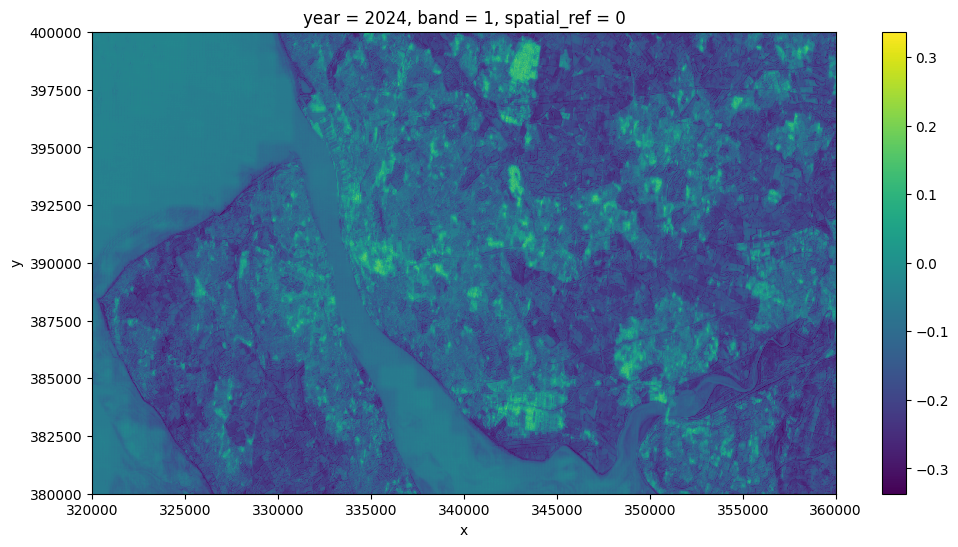

In [29]:
db.sel(year=2024, band=1).plot.imshow(figsize=(12, 6), cmap='viridis')